In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
from transformers import Qwen2_5_VLForConditionalGeneration, AutoTokenizer, AutoProcessor
from qwen_vl_utils import process_vision_info
from PIL import Image
import requests
from io import BytesIO
import numpy as np
import matplotlib.pyplot as plt

# For loading local models
import os
from pathlib import Path

# Optional: for better performance
import accelerate
from transformers import BitsAndBytesConfig

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
model_path = '/home/tumai/models/Qwen--Qwen2.5-VL-7B-Instruct'

In [4]:
# default: Load the model on the available device(s)
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_path, torch_dtype="auto", device_map="auto"
)

# default processer
processor = AutoProcessor.from_pretrained(model_path)

# The default range for the number of visual tokens per image in the model is 4-16384.
# You can set min_pixels and max_pixels according to your needs, such as a token range of 256-1280, to balance performance and cost.
# min_pixels = 256*28*28
# max_pixels = 1280*28*28
# processor = AutoProcessor.from_pretrained("Qwen/Qwen2.5-VL-7B-Instruct", min_pixels=min_pixels, max_pixels=max_pixels)

Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

Some parameters are on the meta device because they were offloaded to the cpu.
The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.
You have video processor config saved in `preprocessor.json` file which is deprecated. Video processor configs should be saved in their own `video_preprocessor.json` file. You can rename the file or load and save the processor back which renames it automatically. Loading from `preprocessor.json` will be removed in v5.0.


In [5]:
messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": "https://img.joomcdn.net/92dcb1525c67772064ad027ee8ca9d1fe6db06c2_original.jpeg",
            },
            {"type": "text", "text": "Describe this image."},
        ],
    }
]

# Preparation for inference
text = processor.apply_chat_template(
    messages, tokenize=False, add_generation_prompt=True
)
image_inputs, video_inputs = process_vision_info(messages)
inputs = processor(
    text=[text],
    images=image_inputs,
    videos=video_inputs,
    padding=True,
    return_tensors="pt",
)
inputs = inputs.to("cuda")

# Inference: Generation of the output
generated_ids = model.generate(**inputs, max_new_tokens=128)
generated_ids_trimmed = [
    out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
]
output_text = processor.batch_decode(
    generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
)
print(output_text)


OutOfMemoryError: CUDA out of memory. Tried to allocate 1.60 GiB. GPU 0 has a total capacity of 23.46 GiB of which 1.22 GiB is free. Process 3088833 has 19.73 GiB memory in use. Including non-PyTorch memory, this process has 2.51 GiB memory in use. Of the allocated memory 1.56 GiB is allocated by PyTorch, and 773.45 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

## Test Run with Chick Chicken

In [ ]:
# Import pipeline components
import sys
sys.path.append('.')  # Add current directory to path

from scene_graph_loader import load_scene_graph_for_frame
from scene_graph_encoder import SceneGraphEncoderFactory
from config_manager import SceneGraphConfig
import json

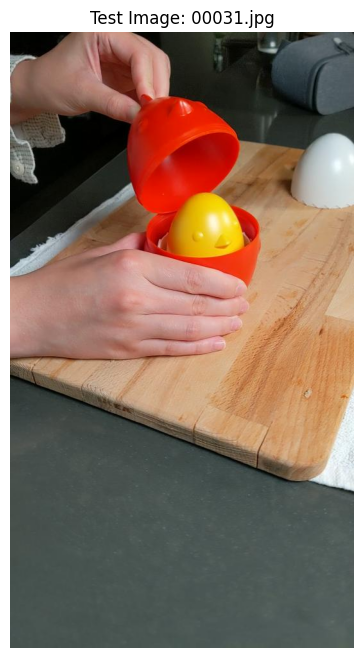

Image size: (536, 960)
Image mode: RGB


In [6]:
# Load the image
from PIL import Image
import matplotlib.pyplot as plt

image_path = "00031.jpg"
image = Image.open(image_path)

# Display the image
plt.figure(figsize=(10, 8))
plt.imshow(image)
plt.axis('off')
plt.title("Test Image: 00031.jpg")
plt.show()

print(f"Image size: {image.size}")
print(f"Image mode: {image.mode}")

In [13]:
# Test loading the GraphML scene graph
graph_path = "chickchicken_graph.graphml"

try:
    # Load the scene graph directly
    scene_graph = load_scene_graph_for_frame(
        graph_dir=".",  # Current directory
        source_type="3d",
        file_path=graph_path,
    )
    
    print("Scene graph loaded successfully!")
    print(f"Scene graph type: {type(scene_graph)}")
    
except Exception as e:
    print(f"Error loading scene graph: {e}")
    print("Let's try loading the GraphML file directly...")
    
    # Fallback: load GraphML directly
    import networkx as nx
    scene_graph = nx.read_graphml(graph_path)
    print("GraphML loaded directly!")
    print(f"Number of nodes: {len(scene_graph.nodes())}")
    print(f"Number of edges: {len(scene_graph.edges())}")

Reconstructed lang_feat -> 512-dim vector
Reconstructed lang_feat -> 512-dim vector
Reconstructed lang_feat -> 512-dim vector
Reconstructed lang_feat -> 512-dim vector
Reconstructed lang_feat -> 512-dim vector
Reconstructed lang_feat -> 512-dim vector
Reconstructed lang_feat -> 512-dim vector
Reconstructed lang_feat -> 512-dim vector
Reconstructed lang_feat -> 512-dim vector
Reconstructed lang_feat -> 512-dim vector
Reconstructed lang_feat -> 512-dim vector
Scene graph loaded successfully!
Scene graph type: <class 'scene_graph_loader.SceneGraph'>


In [14]:
scene_graph

SceneGraph(timestamp=0.0, frame_id='chickchicken_graph', nodes=[SceneNode(id='0', label='object_0', position=None, bbox=None, attributes={'pos_x': -3.502093, 'pos_y': -6.188044, 'pos_z': 25.741873, 'clip_features': [0.06265793, -0.009274473, -0.115368426, -0.0024999566, -0.012146557, 0.014144941, -0.09188753, 0.042611703, 0.016238337, 0.02456325, -0.017576491, 0.007835782, -0.0057129147, 0.0104634315, 0.035914443, -0.00039315858, 0.0424816, -0.010121001, -0.01749631, -3.0432693e-05, -0.010628479, 0.008210636, 0.03417397, -0.0237728, -0.0013824531, -0.0066106208, -0.037243403, 0.02386055, 0.02204374, -0.014997318, 0.0036266258, -0.015869068, 0.008262388, -0.02124136, 0.0045507564, 0.0034853483, -0.006713699, 0.04532325, -0.012729261, -0.026622506, 0.0025611732, 0.014499495, -0.0021794527, -0.046416845, 0.021197893, 0.02954867, -0.094905354, 0.018124444, -0.022162845, -0.0021072924, -0.07178419, -0.019830327, 0.019386778, 0.009975498, -0.018382534, -0.00506729, -0.014521757, -0.01896401,

In [15]:
# Test JSON encoding
print("=== Testing JSON Encoding ===")

json_config = SceneGraphConfig(
    source_type="3d",
    encoding_format="json",
    graph_dir=".",
    include_spatial_info=True,
    include_temporal_info=False
)

json_encoder = SceneGraphEncoderFactory.create_encoder("json")

try:
    json_encoded = json_encoder.encode(scene_graph)
    print("JSON encoding successful!")
    print(f"JSON encoded length: {len(str(json_encoded))}")
    
    # Pretty print first part of JSON
    if isinstance(json_encoded, (dict, list)):
        json_str = json.dumps(json_encoded, indent=2)
        print("\nFirst 1000 characters of JSON encoding:")
        print(json_str[:1000] + "..." if len(json_str) > 1000 else json_str)
    else:
        print(f"JSON encoded (first 500 chars): {str(json_encoded)[:500]}")
        
except Exception as e:
    print(f"Error with JSON encoding: {e}")
    # Manual JSON encoding for GraphML
    manual_json = {
        "objects": [],
        "relationships": [],
        "metadata": {"source": "graphml", "frame": "00031"}
    }
    
    # Extract objects (nodes)
    for node_id, attrs in scene_graph.nodes(data=True):
        obj = {"id": str(node_id), "attributes": dict(attrs)}
        manual_json["objects"].append(obj)
    
    # Extract relationships (edges) 
    for src, dst, attrs in scene_graph.edges(data=True):
        rel = {"subject": str(src), "object": str(dst), "attributes": dict(attrs)}
        manual_json["relationships"].append(rel)
    
    json_encoded = manual_json
    print("Manual JSON encoding created!")
    print(f"Objects: {len(manual_json['objects'])}, Relationships: {len(manual_json['relationships'])}")

=== Testing JSON Encoding ===


/home/tumai/miniconda3/envs/4DSplat/lib/python3.10/site-packages/open_clip/factory.py:388: UserWarning: These pretrained weights were trained with QuickGELU activation but the model config does not have that enabled. Consider using a model config with a "-quickgelu" suffix or enable with a flag.
  warnings.warn(


JSON encoding successful!
JSON encoded length: 189588
JSON encoded (first 500 chars): {
  "frame_id": "chickchicken_graph",
  "timestamp": 0.0,
  "objects": [
    {
      "id": "0",
      "attributes": {
        "label": "object_0",
        "confidence": 1.0,
        "pos_x": -3.502093,
        "pos_y": -6.188044,
        "pos_z": 25.741873
      },
      "semantic_descriptions": {
        "clip_features": {
          "primary": "hernia mesh",
          "confidence": 0.046532269567251205,
          "alternatives": [
            "matte surface",
            "bile duct",
          


In [16]:
json_encoded

'{\n  "frame_id": "chickchicken_graph",\n  "timestamp": 0.0,\n  "objects": [\n    {\n      "id": "0",\n      "attributes": {\n        "label": "object_0",\n        "confidence": 1.0,\n        "pos_x": -3.502093,\n        "pos_y": -6.188044,\n        "pos_z": 25.741873\n      },\n      "semantic_descriptions": {\n        "clip_features": {\n          "primary": "hernia mesh",\n          "confidence": 0.046532269567251205,\n          "alternatives": [\n            "matte surface",\n            "bile duct",\n            "surgical sponge",\n            "shiny surface"\n          ]\n        }\n      },\n      "raw_features": {\n        "clip_features": [\n          0.062657929956913,\n          -0.009274473413825035,\n          -0.11536842584609985,\n          -0.002499956637620926,\n          -0.012146556749939919,\n          0.014144941233098507,\n          -0.09188753366470337,\n          0.042611703276634216,\n          0.016238337382674217,\n          0.024563249200582504,\n          -

In [17]:
# Test Natural Language encoding
print("=== Testing Natural Language Encoding ===")

nl_config = SceneGraphConfig(
    source_type="3d", 
    encoding_format="text",
    graph_dir=".",
    include_spatial_info=True,
    include_temporal_info=False
)

nl_encoder = SceneGraphEncoderFactory.create_encoder("text")

try:
    nl_encoded = nl_encoder.encode(scene_graph)
    print("Natural language encoding successful!")
    print(f"Natural language encoded length: {len(nl_encoded)}")
    print(f"\nNatural language encoding:\n{nl_encoded}")
    
except Exception as e:
    print(f"Error with natural language encoding: {e}")
    # Manual natural language encoding
    nl_parts = ["Scene Description:"]
    
    # Describe objects
    objects = list(scene_graph.nodes(data=True))
    nl_parts.append(f"\nObjects in scene ({len(objects)} total):")
    for node_id, attrs in objects[:10]:  # Limit to first 10
        attr_desc = ", ".join([f"{k}: {v}" for k, v in attrs.items() if v is not None])
        if attr_desc:
            nl_parts.append(f"- {node_id}: {attr_desc}")
        else:
            nl_parts.append(f"- {node_id}")
    
    # Describe relationships
    relationships = list(scene_graph.edges(data=True))
    nl_parts.append(f"\nRelationships ({len(relationships)} total):")
    for src, dst, attrs in relationships[:10]:  # Limit to first 10
        attr_desc = ", ".join([f"{k}: {v}" for k, v in attrs.items() if v is not None])
        if attr_desc:
            nl_parts.append(f"- {src} relates to {dst}: {attr_desc}")
        else:
            nl_parts.append(f"- {src} relates to {dst}")
    
    nl_encoded = "\n".join(nl_parts)
    print("Manual natural language encoding created!")
    print(f"\nManual encoding:\n{nl_encoded}")

=== Testing Natural Language Encoding ===
Natural language encoding successful!
Natural language encoded length: 1497

Natural language encoding:
Scene Description:

Objects (11 total):
- Object 0 (hernia mesh, confidence: 0.047, alternatives: matte surface, bile duct) [label: object_...
- Object 1 (abdominal wall, confidence: 0.026, alternatives: abdominal muscle, peritoneal fat) [lab...
- Object 2 (hernia mesh, confidence: 0.061, alternatives: matte surface, surgical sponge) [label: o...
- Object 3 (hernia mesh, confidence: 0.051, alternatives: matte surface, bile duct) [label: object_...
- Object 4 (electrocautery hook, confidence: 0.062, alternatives: surgical sponge, laparoscope) [la...
- Object 5 (surgical sponge, confidence: 0.027, alternatives: hernia mesh, matte surface) [label: o...
- Object 6 (matte surface, confidence: 0.076, alternatives: hernia mesh, surgical sponge) [label: o...
- Object 7 (peritoneum, confidence: 0.018, alternatives: aspirator, peritoneal fat) [label: o

In [ ]:
# Test feature vector reconstruction
print("=== Testing Feature Vector Reconstruction ===")

# Check current node structure
sample_node_id, sample_attrs = list(scene_graph.nodes(data=True))[0]
print(f"Sample node ID: {sample_node_id}")
print(f"Sample node attributes keys: {list(sample_attrs.keys())[:10]}...")

# Look for feature patterns
feat_keys = [k for k in sample_attrs.keys() if '_feat_' in k and k.split('_')[-1].isdigit()]
print(f"Found {len(feat_keys)} individual feature attributes")

if feat_keys:
    print(f"Feature pattern examples: {feat_keys[:5]}")
    
    # Show the problem: individual values instead of vectors
    for key in feat_keys[:3]:
        print(f"  {key}: {sample_attrs[key]}")
    
    # Reconstruct manually to demonstrate the fix
    from scene_graph_loader import Single3DSceneGraphLoader
    loader = Single3DSceneGraphLoader()
    
    reconstructed = loader._reconstruct_feature_vectors(sample_attrs)
    
    print("\nAfter reconstruction:")
    for key, value in reconstructed.items():
        if 'features' in key or 'vector' in key:
            if isinstance(value, list):
                print(f"  {key}: {len(value)}-dimensional vector")
                print(f"    First 5 values: {value[:5]}")
            else:
                print(f"  {key}: {value}")
else:
    print("No broken individual features found - features may already be properly formatted!")
    
    # Check for existing feature vectors
    feature_attrs = [k for k in sample_attrs.keys() if any(indicator in k.lower() for indicator in ['clip', 'feature', 'embedding', 'vector'])]
    if feature_attrs:
        print(f"Found existing feature attributes: {feature_attrs}")
        for key in feature_attrs:
            value = sample_attrs[key]
            if isinstance(value, list):
                print(f"  {key}: {len(value)}-dimensional vector")
            else:
                print(f"  {key}: {type(value)} - {str(value)[:50]}...")

In [ ]:
# Add this cell to test enhanced feature processing:

# Test enhanced feature processing
print("=== Testing Enhanced Feature Processing ===")

# Try to import and test the feature processor directly
try:
    from feature_processor import FeatureProcessor
    
    # Create feature processor
    feature_processor = FeatureProcessor(
        enable_feature_decoding=True,
        enable_raw_features=True
    )
    
    # Test processing a node with features
    print("\n--- Processing Individual Node ---")
    sample_node_id, sample_attrs = list(scene_graph.nodes(data=True))[0]
    print(f"Processing node {sample_node_id}...")
    
    processed = feature_processor.process_node_features(str(sample_node_id), sample_attrs)
    print(f"Original attributes: {len(processed['original_attributes'])} items")
    print(f"Decoded features: {len(processed['decoded_features'])} items")
    print(f"Raw features: {len(processed['raw_features'])} items")
    
    # Show decoded features
    for feature_key, decoded in processed["decoded_features"].items():
        print(f"\n{feature_key} decoded:")
        print(f"  Primary: {decoded.get('primary_description', 'N/A')}")
        print(f"  Confidence: {decoded.get('confidence', 0):.3f}")
        print(f"  Alternatives: {decoded.get('alternative_descriptions', [])[:3]}")
    
    # Create textual description
    description = feature_processor.create_textual_description(processed)
    print(f"\nTextual description: {description}")
    
except ImportError as e:
    print(f"Feature processor not available: {e}")
    print("This is expected if the feature_processor.py file hasn't been created yet.")

except Exception as e:
    print(f"Error testing feature processor: {e}")
    import traceback
    traceback.print_exc()

In [ ]:
# Test the complete enhanced encoding pipeline
print("=== Testing Complete Enhanced Encoding ===")

# Test with 3D loader (fixed)
try:
    print("Testing 3D scene graph loading...")
    from scene_graph_loader import load_scene_graph_for_frame
    
    # Load as 3D scene graph (this should now work properly)
    scene_graph_3d = load_scene_graph_for_frame(
        graph_dir=".",
        source_type="3d",  # Use 3D instead of 4D
        file_path="chickchicken_graph.graphml"
    )
    
    if scene_graph_3d:
        print(f"3D scene graph loaded: {len(scene_graph_3d.nodes)} nodes, {len(scene_graph_3d.edges)} edges")
        
        # Test enhanced text encoding
        text_encoder = SceneGraphEncoderFactory.create_encoder(
            "text", 
            enable_feature_decoding=True
        )
        
        enhanced_text = text_encoder.encode(scene_graph_3d)
        print(f"\nEnhanced text encoding (first 500 chars):")
        print(enhanced_text[:500] + "..." if len(enhanced_text) > 500 else enhanced_text)
    
except Exception as e:
    print(f"Error with 3D loading: {e}")
    print("Falling back to NetworkX graph...")
    
    # Fallback: use the existing NetworkX graph but test manual reconstruction
    try:
        # Manually create enhanced encoder
        from scene_graph_encoder import TextSceneGraphEncoder
        
        enhanced_encoder = TextSceneGraphEncoder(enable_feature_decoding=True)
        enhanced_text = enhanced_encoder.encode(scene_graph)
        
        print(f"Enhanced encoding successful!")
        print(f"Length: {len(enhanced_text)} characters")
        print(f"First 500 characters:\n{enhanced_text[:500]}")
        
    except Exception as e2:
        print(f"Enhanced encoding failed: {e2}")
        import traceback
        traceback.print_exc()

In [ ]:
from feature_processor import create_feature_processor_from_preset

In [ ]:
# Option 1: Pass feature processor directly
feature_proc = create_feature_processor_from_preset("fast_inference")
encoder = SceneGraphEncoderFactory.create_encoder("text", feature_processor=feature_proc)

/home/tumai/miniconda3/envs/4DSplat/lib/python3.10/site-packages/open_clip/factory.py:388: UserWarning: These pretrained weights were trained with QuickGELU activation but the model config does not have that enabled. Consider using a model config with a "-quickgelu" suffix or enable with a flag.
  warnings.warn(


In [26]:
# load scene graph
from scene_graph_loader import Single3DSceneGraphLoader
loader = Single3DSceneGraphLoader()

In [ ]:
# Import the consistent feature processor (FIXED)
import sys
sys.path.append('/home/tumai/team1/Ken/4DLangSplatSurgery/preprocess')
from consistent_feature_processor import create_consistent_feature_processor

In [ ]:
# Create consistent feature processor (FIXED)
consistent_processor = create_consistent_feature_processor('default')
print('✓ Consistent feature processor created successfully')
print(f'✓ Using {len(consistent_processor.vocabulary)} vocabulary terms for enhanced detection')

/home/tumai/miniconda3/envs/4DSplat/lib/python3.10/site-packages/open_clip/factory.py:388: UserWarning: These pretrained weights were trained with QuickGELU activation but the model config does not have that enabled. Consider using a model config with a "-quickgelu" suffix or enable with a flag.
  warnings.warn(


Loaded Open-CLIP model: ViT-B-32 with openai weights
GeneralCLIPFeatureDecoder initialized with 148 general terms


In [33]:
scene_graph = loader.load_scene_graph('chickchicken_graph.graphml')

Reconstructed lang_feat -> 512-dim vector
Reconstructed lang_feat -> 512-dim vector
Reconstructed lang_feat -> 512-dim vector
Reconstructed lang_feat -> 512-dim vector
Reconstructed lang_feat -> 512-dim vector
Reconstructed lang_feat -> 512-dim vector
Reconstructed lang_feat -> 512-dim vector
Reconstructed lang_feat -> 512-dim vector
Reconstructed lang_feat -> 512-dim vector
Reconstructed lang_feat -> 512-dim vector
Reconstructed lang_feat -> 512-dim vector


In [34]:
scene_graph

SceneGraph(timestamp=0.0, frame_id='chickchicken_graph', nodes=[SceneNode(id='0', label='object_0', position=None, bbox=None, attributes={'pos_x': -3.502093, 'pos_y': -6.188044, 'pos_z': 25.741873, 'clip_features': [0.06265793, -0.009274473, -0.115368426, -0.0024999566, -0.012146557, 0.014144941, -0.09188753, 0.042611703, 0.016238337, 0.02456325, -0.017576491, 0.007835782, -0.0057129147, 0.0104634315, 0.035914443, -0.00039315858, 0.0424816, -0.010121001, -0.01749631, -3.0432693e-05, -0.010628479, 0.008210636, 0.03417397, -0.0237728, -0.0013824531, -0.0066106208, -0.037243403, 0.02386055, 0.02204374, -0.014997318, 0.0036266258, -0.015869068, 0.008262388, -0.02124136, 0.0045507564, 0.0034853483, -0.006713699, 0.04532325, -0.012729261, -0.026622506, 0.0025611732, 0.014499495, -0.0021794527, -0.046416845, 0.021197893, 0.02954867, -0.094905354, 0.018124444, -0.022162845, -0.0021072924, -0.07178419, -0.019830327, 0.019386778, 0.009975498, -0.018382534, -0.00506729, -0.014521757, -0.01896401,

In [35]:
encoder = SceneGraphEncoderFactory.create_encoder("text", feature_processor=consistent_processor)

In [36]:
encoded_scene_graph = encoder.encode(scene_graph)

In [48]:
print("=== General Vocabulary Encoding ===")
print(encoded_scene_graph[:800])  # Show first 800 characters

# Test with individual node to see the difference
print("\n=== Individual Node Comparison ===")
sample_node_id, sample_attrs = list(scene_graph.nodes)[0].id, list(scene_graph.nodes)[0].attributes

# Process with general processor
general_processed = consistent_processor.process_node_features(str(sample_node_id), sample_attrs)
general_description = consistent_processor.create_textual_description(general_processed)
print(f"General processor result: {general_description}")

# Show decoded features details
if general_processed["decoded_features"]:
    for feature_key, decoded in general_processed["decoded_features"].items():
        print(f"\n{feature_key} -> Top matches:")
        for term, confidence in decoded.get("all_matches", [])[:5]:
            print(f"  {term}: {confidence:.3f}")

=== General Vocabulary Encoding ===
Scene Description:

Objects (11 total):
- Object 0 (green, confidence: 0.068, alternatives: purple, colorful) [label: object_0, confidence:...
- Object 1 (purple, confidence: 0.055, alternatives: green, colorful) [label: object_1, confidence:...
- Object 2 (purple, confidence: 0.077, alternatives: green, colorful) [label: object_2, confidence:...
- Object 3 (green, confidence: 0.070, alternatives: purple, colorful) [label: object_3, confidence:...
- Object 4 (colorful, confidence: 0.074, alternatives: purple, green) [label: object_4, confidence:...
- Object 5 (green, confidence: 0.063, alternatives: purple, colorful) [label: object_5, confidence:...
- Object 6 (purple, confidence: 0.100, alternatives: colorful, green) [label: object_6, confidence:...
- Object 7 (sofa, confidence: 0.036, al

=== Individual Node Comparison ===
General processor result: Object 0 (green, confidence: 0.068, alternatives: purple, colorful) [pos_x: -3.502093, pos_y: -6....


## Complete pipeline test

In [53]:
print("=== Complete Pipeline Test: Image + Scene Graph → MLLM ===")
print(f"Image: {image_path}")
print(f"Scene Graph: {graph_path}")
print(f"Model: {model_path}")
print()

=== Complete Pipeline Test: Image + Scene Graph → MLLM ===
Image: 00031.jpg
Scene Graph: chickchicken_graph.graphml
Model: /home/tumai/models/Qwen--Qwen2.5-VL-7B-Instruct



In [56]:
scene_encoder = SceneGraphEncoderFactory.create_encoder("text", feature_processor=consistent_processor)

print("✓ General vocabulary processor created")
print("✓ Text encoder created")

✓ General vocabulary processor created
✓ Text encoder created


In [57]:
# Generate the enhanced scene graph description
enhanced_scene_description = scene_encoder.encode(scene_graph)

print("=== Enhanced Scene Graph Description ===")
print(f"Length: {len(enhanced_scene_description)} characters")
print()
print(enhanced_scene_description)
print()
print("=" * 60)

=== Enhanced Scene Graph Description ===
Length: 1497 characters

Scene Description:

Objects (11 total):
- Object 0 (green, confidence: 0.068, alternatives: purple, colorful) [label: object_0, confidence:...
- Object 1 (purple, confidence: 0.055, alternatives: green, colorful) [label: object_1, confidence:...
- Object 2 (purple, confidence: 0.077, alternatives: green, colorful) [label: object_2, confidence:...
- Object 3 (green, confidence: 0.070, alternatives: purple, colorful) [label: object_3, confidence:...
- Object 4 (colorful, confidence: 0.074, alternatives: purple, green) [label: object_4, confidence:...
- Object 5 (green, confidence: 0.063, alternatives: purple, colorful) [label: object_5, confidence:...
- Object 6 (purple, confidence: 0.100, alternatives: colorful, green) [label: object_6, confidence:...
- Object 7 (sofa, confidence: 0.036, alternatives: purple, truck) [label: object_7, confidence: 1.0...
- Object 8 (colorful, confidence: 0.074, alternatives: purple, green) 

In [ ]:
# Create different types of questions to test the pipeline
test_questions = [
    {
        "type": "basic_description", 
        "question": "What do you see in this image? Describe the main objects and their relationships."
    },
    {
        "type": "specific_object",
        "question": "What type of food is shown in the image? Describe its appearance and condition."
    },
    {
        "type": "scene_graph_integration",
        "question": "Based on the scene graph information provided, what objects are present and how do they relate to each other in the image?"
    },
    {
        "type": "counting",
        "question": "How many distinct objects can you identify in this image?"
    },
    {
        "type": "spatial_reasoning", 
        "question": "Describe the spatial relationships between the objects in the image. What is next to what?"
    },
    {
        "type": "visual_information",
        "question": "Where is the other half of the egg shell that is on the wooden board?"
    }
]

print("=== Test Questions Prepared ===")
for i, q in enumerate(test_questions, 1):
    print(f"{i}. {q['type']}: {q['question']}")

=== Test Questions Prepared ===
1. basic_description: What do you see in this image? Describe the main objects and their relationships.
2. specific_object: What type of food is shown in the image? Describe its appearance and condition.
3. scene_graph_integration: Based on the scene graph information provided, what objects are present and how do they relate to each other in the image?
4. counting: How many distinct objects can you identify in this image?
5. spatial_reasoning: Describe the spatial relationships between the objects in the image. What is next to what?


In [60]:
# Test 1: Baseline - Image only (no scene graph)
print("=== TEST 1: Baseline (Image Only) ===")

baseline_messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": image_path,  # Use your local image
            },
            {"type": "text", "text": test_questions[0]["question"]},
        ],
    }
]

# Process baseline
baseline_text = processor.apply_chat_template(baseline_messages, tokenize=False, add_generation_prompt=True)
baseline_image_inputs, baseline_video_inputs = process_vision_info(baseline_messages)
baseline_inputs = processor(
    text=[baseline_text],
    images=baseline_image_inputs,
    videos=baseline_video_inputs,
    padding=True,
    return_tensors="pt",
)
baseline_inputs = baseline_inputs.to("cuda")

# Generate baseline response
print("Generating baseline response...")
baseline_generated_ids = model.generate(**baseline_inputs, max_new_tokens=200)
baseline_generated_ids_trimmed = [
    out_ids[len(in_ids) :] for in_ids, out_ids in zip(baseline_inputs.input_ids, baseline_generated_ids)
]
baseline_output = processor.batch_decode(
    baseline_generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
)

print("BASELINE RESPONSE (Image Only):")
print(baseline_output[0])
print("\n" + "="*60 + "\n")

=== TEST 1: Baseline (Image Only) ===
Generating baseline response...
BASELINE RESPONSE (Image Only):
In the image, there is a person's hands interacting with a red plastic object that resembles an egg holder or a toy. The red object has a hollow top that is being lifted by one hand, revealing a yellow object inside, which looks like a small, plastic chick or a similar toy. The red object is placed on a wooden cutting board, and part of a white cloth is visible underneath the board. In the background, there is another white object that appears to be another egg holder or a similar item. The setting seems to be a kitchen or a similar indoor environment.




In [59]:
# Test 2: Enhanced - Image + Scene Graph  
print("=== TEST 2: Enhanced (Image + Scene Graph) ===")

# Create enhanced prompt with scene graph information
enhanced_question = f"""Here is an image and its corresponding scene graph analysis:

SCENE GRAPH INFORMATION:
{enhanced_scene_description}

QUESTION: {test_questions[2]["question"]}

Please use both the visual information from the image and the structured scene graph data to provide a comprehensive answer."""

enhanced_messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image", 
                "image": image_path,
            },
            {"type": "text", "text": enhanced_question},
        ],
    }
]

# Process enhanced
enhanced_text = processor.apply_chat_template(enhanced_messages, tokenize=False, add_generation_prompt=True)
enhanced_image_inputs, enhanced_video_inputs = process_vision_info(enhanced_messages)
enhanced_inputs = processor(
    text=[enhanced_text],
    images=enhanced_image_inputs, 
    videos=enhanced_video_inputs,
    padding=True,
    return_tensors="pt",
)
enhanced_inputs = enhanced_inputs.to("cuda")

# Generate enhanced response
print("Generating enhanced response...")
enhanced_generated_ids = model.generate(**enhanced_inputs, max_new_tokens=250)
enhanced_generated_ids_trimmed = [
    out_ids[len(in_ids) :] for in_ids, out_ids in zip(enhanced_inputs.input_ids, enhanced_generated_ids)
]
enhanced_output = processor.batch_decode(
    enhanced_generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
)

print("ENHANCED RESPONSE (Image + Scene Graph):")
print(enhanced_output[0])
print("\n" + "="*60 + "\n")

=== TEST 2: Enhanced (Image + Scene Graph) ===
Generating enhanced response...
ENHANCED RESPONSE (Image + Scene Graph):
Based on the image and the provided scene graph analysis, here's a detailed breakdown of the objects and their relationships:

### Objects Present in the Image:
1. **Red Egg Cup**: A red plastic egg cup with a yellow egg inside.
2. **Yellow Egg**: A yellow egg nestled inside the red egg cup.
3. **Hands**: Two hands interacting with the egg cup.
4. **Wooden Cutting Board**: A wooden surface where the egg cup and hands are placed.
5. **White Egg**: A white egg visible in the background.

### Relationships Between Objects:
The scene graph provides spatial relationships between objects, which can be interpreted as follows:

1. **Spatial Relationship 0**:
   - **Object 0**: Green (confidence: 0.068, alternatives: purple, colorful).
   - **Object 9**: Sofa (confidence: 0.041, alternatives: purple, green).

2. **Spatial Relationship 1**:
   - **Object 1**: Purple (confidence

In [61]:
# Compare the results
print("=== COMPARISON: Baseline vs Enhanced ===")
print()

print("BASELINE (Image Only):")
print("-" * 40)
print(baseline_output[0])
print()

print("ENHANCED (Image + Scene Graph):")  
print("-" * 40)
print(enhanced_output[0])
print()

print("ANALYSIS:")
print("-" * 40)
baseline_length = len(baseline_output[0])
enhanced_length = len(enhanced_output[0])
print(f"• Baseline response length: {baseline_length} characters")
print(f"• Enhanced response length: {enhanced_length} characters")
print(f"• Length difference: {enhanced_length - baseline_length:+d} characters")

# Simple keyword analysis
baseline_words = set(baseline_output[0].lower().split())
enhanced_words = set(enhanced_output[0].lower().split()) 
new_words = enhanced_words - baseline_words
print(f"• New words in enhanced response: {len(new_words)}")
if new_words:
    print(f"  Examples: {list(new_words)[:10]}")

=== COMPARISON: Baseline vs Enhanced ===

BASELINE (Image Only):
----------------------------------------
In the image, there is a person's hands interacting with a red plastic object that resembles an egg holder or a toy. The red object has a hollow top that is being lifted by one hand, revealing a yellow object inside, which looks like a small, plastic chick or a similar toy. The red object is placed on a wooden cutting board, and part of a white cloth is visible underneath the board. In the background, there is another white object that appears to be another egg holder or a similar item. The setting seems to be a kitchen or a similar indoor environment.

ENHANCED (Image + Scene Graph):
----------------------------------------
Based on the image and the provided scene graph analysis, here's a detailed breakdown of the objects and their relationships:

### Objects Present in the Image:
1. **Red Egg Cup**: A red plastic egg cup with a yellow egg inside.
2. **Yellow Egg**: A yellow egg 

In [62]:
# Test different question types with the enhanced pipeline
print("=== TESTING DIFFERENT QUESTION TYPES ===")

for i, question_data in enumerate(test_questions[1:4], 2):  # Test questions 2-4
    print(f"\n--- TEST {i}: {question_data['type'].upper()} ---")
    
    # Create question with scene graph
    specific_question = f"""Scene Graph Analysis:
{enhanced_scene_description[:400]}...

Question: {question_data['question']}"""
    
    specific_messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image_path},
                {"type": "text", "text": specific_question},
            ],
        }
    ]
    
    # Process
    specific_text = processor.apply_chat_template(specific_messages, tokenize=False, add_generation_prompt=True)
    specific_image_inputs, specific_video_inputs = process_vision_info(specific_messages)
    specific_inputs = processor(
        text=[specific_text],
        images=specific_image_inputs,
        videos=specific_video_inputs, 
        padding=True,
        return_tensors="pt",
    )
    specific_inputs = specific_inputs.to("cuda")
    
    # Generate
    print(f"Generating response for {question_data['type']}...")
    specific_generated_ids = model.generate(**specific_inputs, max_new_tokens=150)
    specific_generated_ids_trimmed = [
        out_ids[len(in_ids) :] for in_ids, out_ids in zip(specific_inputs.input_ids, specific_generated_ids)
    ]
    specific_output = processor.batch_decode(
        specific_generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
    )
    
    print("RESPONSE:")
    print(specific_output[0])
    print("-" * 50)

=== TESTING DIFFERENT QUESTION TYPES ===

--- TEST 2: SPECIFIC_OBJECT ---
Generating response for specific_object...
RESPONSE:
The image shows a toy rather than actual food. The toy appears to be a small, yellow, plastic chick inside an orange plastic egg-shaped container. The chick has a simple design with a face drawn on it. The container is open, revealing the chick inside. The scene is set on a wooden cutting board, which suggests that this might be part of a play or demonstration setup, possibly for children's activities or educational purposes. There is no actual food present in the image.
--------------------------------------------------

--- TEST 3: SCENE_GRAPH_INTEGRATION ---
Generating response for scene_graph_integration...
RESPONSE:
The scene graph analysis seems to be incomplete or incorrect as it does not match the actual objects in the image. The image shows a person's hands interacting with a red plastic container that has an orange lid, which is open to reveal a yello

In [66]:
# Analyze the quality of your scene graph processing
print("=== SCENE GRAPH QUALITY ANALYSIS ===")

# Check what features were decoded
sample_nodes = list(scene_graph.nodes)[:3]  # Check first 3 nodes

for i, node in enumerate(sample_nodes):
    print(f"\n--- NODE {i+1}: {node} ---")

    # Process this node specifically
    processed_node = consistent_processor.process_node_features(str(node), scene_graph.nodes[i].attributes)
    print(f"Original attributes: {len(processed_node['original_attributes'])}")
    print(f"Decoded features: {len(processed_node['decoded_features'])}")
    
    # Show decoded features
    if processed_node["decoded_features"]:
        for feature_key, decoded in processed_node["decoded_features"].items():
            print(f"  {feature_key}:")
            print(f"    Primary: {decoded.get('primary_description', 'N/A')}")
            print(f"    Confidence: {decoded.get('confidence', 0):.3f}")
            if decoded.get('alternative_descriptions'):
                print(f"    Alternatives: {decoded['alternative_descriptions'][:2]}")
    
    # Show original attributes
    if processed_node["original_attributes"]:
        print(f"  Other attributes: {list(processed_node['original_attributes'].keys())}")

print(f"\n--- SUMMARY ---")
total_nodes = len(scene_graph.nodes)
total_edges = len(scene_graph.edges) 
print(f"• Total nodes: {total_nodes}")
print(f"• Total edges: {total_edges}")
print(f"• Scene graph description length: {len(enhanced_scene_description)} chars")

=== SCENE GRAPH QUALITY ANALYSIS ===

--- NODE 1: SceneNode(id='0', label='object_0', position=None, bbox=None, attributes={'pos_x': -3.502093, 'pos_y': -6.188044, 'pos_z': 25.741873, 'clip_features': [0.06265793, -0.009274473, -0.115368426, -0.0024999566, -0.012146557, 0.014144941, -0.09188753, 0.042611703, 0.016238337, 0.02456325, -0.017576491, 0.007835782, -0.0057129147, 0.0104634315, 0.035914443, -0.00039315858, 0.0424816, -0.010121001, -0.01749631, -3.0432693e-05, -0.010628479, 0.008210636, 0.03417397, -0.0237728, -0.0013824531, -0.0066106208, -0.037243403, 0.02386055, 0.02204374, -0.014997318, 0.0036266258, -0.015869068, 0.008262388, -0.02124136, 0.0045507564, 0.0034853483, -0.006713699, 0.04532325, -0.012729261, -0.026622506, 0.0025611732, 0.014499495, -0.0021794527, -0.046416845, 0.021197893, 0.02954867, -0.094905354, 0.018124444, -0.022162845, -0.0021072924, -0.07178419, -0.019830327, 0.019386778, 0.009975498, -0.018382534, -0.00506729, -0.014521757, -0.01896401, -0.012395843,